In [23]:
# Importing modules

import numpy as np #Numerical calculation
import matplotlib.pyplot as plt   # 2D display
from scipy.integrate import odeint   #differential system solving
from mpl_toolkits.mplot3d import Axes3D  # 3D display

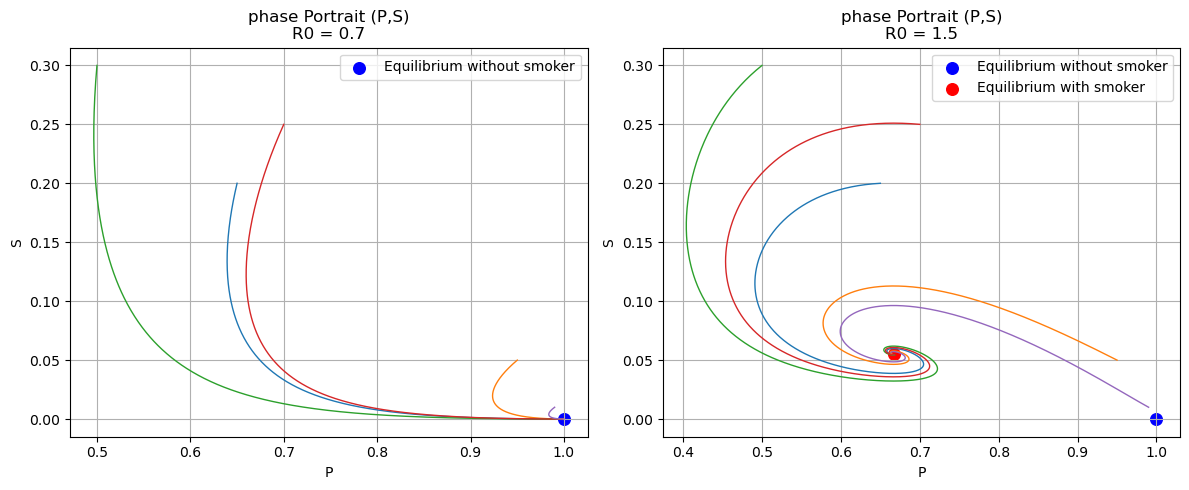

In [24]:
# system

def model(y, t, mu, beta, gamma, N):
    P, S, Q = y
    dPdt = mu - beta * P * S / N - mu * P
    dSdt = beta * P * S / N - (mu + gamma) * S
    dQdt = gamma * S - mu * Q
    return [dPdt, dSdt, dQdt]

# Parameters

mu = 0.02
gamma = 0.1
N = 1.0
t = np.linspace(0, 300, 2000) # the number of day (0 to 300), so 10 months

R0_values = [0.7, 1.5]  # stable for DSF / stable for E*

# Multiple initial conditions
ICs = [
    [0.65, 0.2, 0.15],
    [0.95, 0.05, 0.0],
    [0.5, 0.3, 0.2],
    [0.7, 0.25, 0.05],
    [0.99, 0.01, 0.0]
]


# PHASE PORTRAIT (P,S)

plt.figure(figsize=(12, 5))

for i, R0 in enumerate(R0_values):
    beta = R0 * (mu + gamma)

    plt.subplot(1, 2, i+1)

    # Trajectories
    for y0 in ICs:
        sol = odeint(model, y0, t, args=(mu, beta, gamma, N))
        P, S, Q = sol.T
        plt.plot(P, S, lw=1)

    # Equilibrium without smoker
    plt.scatter(N, 0, color="blue", s=70, label="Equilibrium without smoker")

    # Endemic equilibrium if R0 > 1
    if R0 > 1:
        P_en = N / R0
        S_en = mu * N * (R0 - 1) / beta
        plt.scatter(P_en, S_en, color="red", s=70, label="Equilibrium with smoker")

    plt.xlabel("P")
    plt.ylabel("S")
    plt.title(f"phase Portrait (P,S)\nR0 = {R0}")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

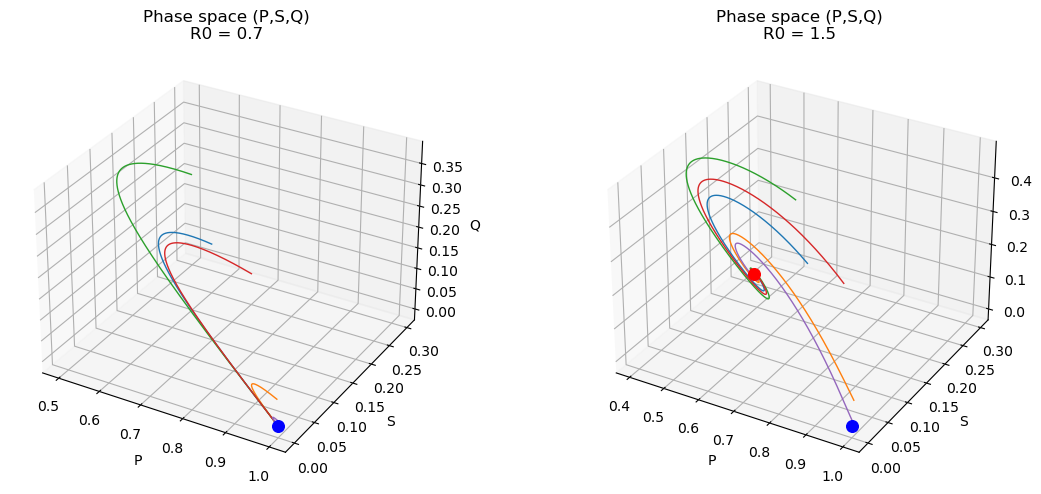

In [25]:
# Phase portrait in the surface (P,S,Q)

fig = plt.figure(figsize=(12, 5))

for i, R0 in enumerate(R0_values):
    beta = R0 * (mu + gamma)
    ax = fig.add_subplot(1, 2, i+1, projection="3d")

    for y0 in ICs:
        sol = odeint(model, y0, t, args=(mu, beta, gamma, N))
        P, S, Q = sol.T
        ax.plot(P, S, Q, lw=1)

    # Équilibre sans maladie
    ax.scatter(N, 0, 0, color="blue", s=70)

    # Équilibre endémique
    if R0 > 1:
        P_en = N / R0
        S_en = mu * N * (R0 - 1) / beta
        Q_en = gamma * S_en / mu
        ax.scatter(P_en, S_en, Q_en, color="red", s=70)

    ax.set_xlabel("P")
    ax.set_ylabel("S")
    ax.set_zlabel("Q")
    ax.set_title(f"Phase space (P,S,Q)\nR0 = {R0}")

plt.tight_layout()
plt.show()

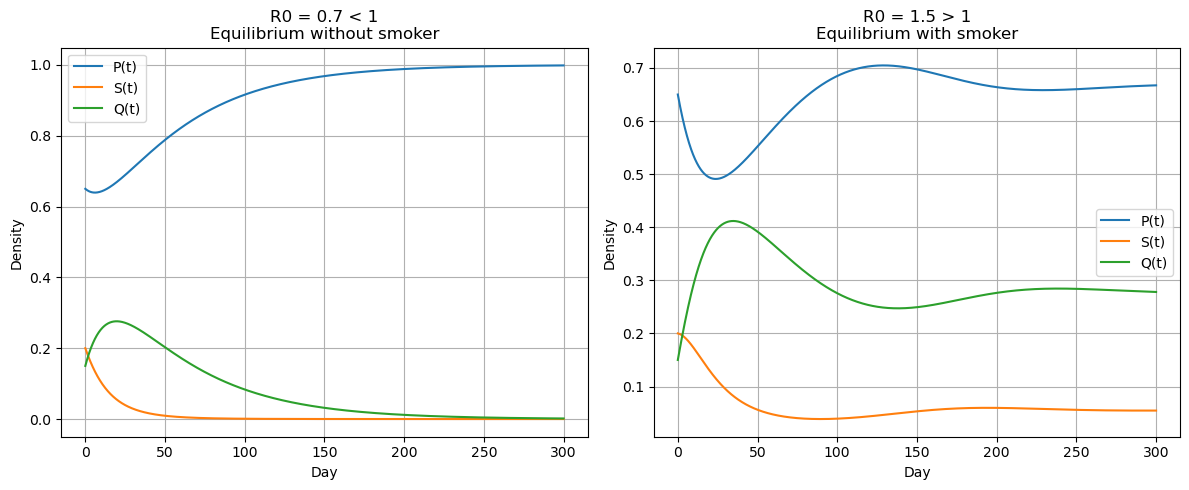

In [26]:
# Visualization based on the number of days t

plt.figure(figsize=(12, 5))

y0 = [0.65, 0.2, 0.15]

for i, R0 in enumerate(R0_values):
    beta = R0 * (mu + gamma)

    sol = odeint(model, y0, t, args=(mu, beta, gamma, N))
    P, S, Q = sol.T

    plt.subplot(1, 2, i+1)
    plt.plot(t, P, label="P(t)")
    plt.plot(t, S, label="S(t)")
    plt.plot(t, Q, label="Q(t)")

    if R0 < 1:
        plt.title(f"R0 = {R0} < 1\nEquilibrium without smoker")
    else:
        plt.title(f"R0 = {R0} > 1\nEquilibrium with smoker")

    plt.xlabel("Day")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()
